# Baseline Model — Ring Galaxy Classification

Este notebook construye el modelo de referencia para el problema de clasificación binaria:
- **Clase 0**: Galaxia sin anillo
- **Clase 1**: Galaxia con anillo ( basandonos en la referencia de anillo interno )

## Diseño

| Decisión | Elección | Razón |
|----------|----------|-------|
| Métrica principal | F1-macro + PR-AUC | Desbalance 79/21 |
| Algoritmo baseline | Random Forest | Robusto, no requiere normalización, da importancia de features |
| Importancia de features | Permutation Importance | Más confiable que `feature_importances_` bajo colinealidad |
| Desbalance | `class_weight='balanced'` | Penaliza más los errores sobre la clase minoritaria (ring) |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DATA_PATH = '../feature_engineering/output/feature_engineered_dataset.csv'

### Carga de datos y procesamiento

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(2)

Shape: (8408, 108)


,name,source,anillos,label,split,has_fits,has_image_features,fits_path,objra,objdec,...,pca_10,pca_11,pca_12,pca_13,pca_14,pca_15,pca_16,pca_17,fa_1,fa_2
0,1237648721210769659,sdss,0,0,train,1,1,/home/camilo/Documents/school/proyecto-integra...,134.44717,-0.199973,...,-0.954553,0.185764,-0.660925,0.392685,1.030705,-0.869769,-0.226320,-0.067297,-0.055243,0.459087
1,1237648705657307354,sdss,0,0,test,1,1,/home/camilo/Documents/school/proyecto-integra...,198.23356,0.941188,...,-1.068654,0.713673,-1.040353,1.286345,0.770179,-0.712608,-0.004687,0.373202,-0.505531,-0.879039


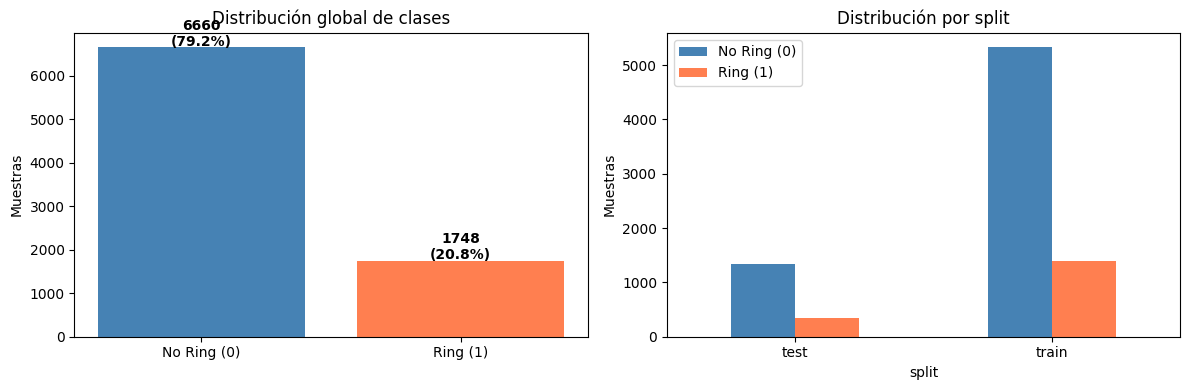

Ratio desbalance: 3.81:1
Train: 6726 muestras | Test: 1682 muestras


In [4]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
axes[0].bar(['No Ring (0)', 'Ring (1)'], counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Distribución global de clases')
axes[0].set_ylabel('Muestras')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

split_counts = df.groupby(['split', 'label']).size().unstack(fill_value=0)
split_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], rot=0)
axes[1].set_title('Distribución por split')
axes[1].set_ylabel('Muestras')
axes[1].legend(['No Ring (0)', 'Ring (1)'])

plt.tight_layout()
plt.show()

print(f'Ratio desbalance: {counts[0]/counts[1]:.2f}:1')
print(f'Train: {split_counts.loc["train"].sum()} muestras | Test: {split_counts.loc["test"].sum()} muestras')

In [5]:
# Columnas de features vs la metadata
META_COLS = ['name', 'source', 'anillos', 'label', 'split', 'has_fits', 'has_image_features', 'fits_path']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

print(f'Total features: {len(FEATURE_COLS)}')
groups = {
    'Imagen (img_*)': [c for c in FEATURE_COLS if c.startswith('img_')],
    'Lupton RGB (lupton_*)': [c for c in FEATURE_COLS if c.startswith('lupton_')],
    'PCA (pca_*)': [c for c in FEATURE_COLS if c.startswith('pca_')],
    'Factor Analysis (fa_*)': [c for c in FEATURE_COLS if c.startswith('fa_')],
    'Geoespaciales': [c for c in FEATURE_COLS if c in ['ra_sin','ra_cos','dec_sin','dec_cos','gal_l','gal_b','gal_l_sin','gal_l_cos','gal_b_sin','gal_b_abs']],
    'Redshift (z_*)': [c for c in FEATURE_COLS if c.startswith('z_')],
    'Bins (z_bin_*)': [c for c in FEATURE_COLS if c.startswith('z_bin_')],
}
for grp, cols in groups.items():
    print(f'  {grp}: {len(cols)}')

# Imagenes que no esta agregadas a features, ya sea que no se descargaron o no se procesaron
null_counts = df[FEATURE_COLS].isnull().sum()
print(f'\nMuestras con algún nulo: {df[FEATURE_COLS].isnull().any(axis=1).sum()} ({df[FEATURE_COLS].isnull().any(axis=1).mean()*100:.1f}%)')

Total features: 100
  Imagen (img_*): 28
  Lupton RGB (lupton_*): 26
  PCA (pca_*): 17
  Factor Analysis (fa_*): 2
  Geoespaciales: 10
  Redshift (z_*): 7
  Bins (z_bin_*): 4

Muestras con algún nulo: 307 (3.7%)


### Preparación de datos

Los 307 registros sin FITS tienen valores nulos en todas las features de imagen, esto de debe a que no se encuentran descargadas las imagenes o estan corruptas, por lo que se imputa con la **mediana** — Random Forest tolera esta estrategia y es neutral respecto a la distribución de clases.

In [6]:
train_df = df[df['split'] == 'train'].copy()
test_df  = df[df['split'] == 'test'].copy()

X_train_raw = train_df[FEATURE_COLS]
X_test_raw  = test_df[FEATURE_COLS]
y_train = train_df['label'].values
y_test  = test_df['label'].values

# Imputación de medianas fit solo en train
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train_raw)
X_test  = imputer.transform(X_test_raw)

print(f'X_train: {X_train.shape} | y_train ring: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'X_test:  {X_test.shape}  | y_test ring:  {y_test.sum()} ({y_test.mean()*100:.1f}%)')

X_train: (6726, 100) | y_train ring: 1398 (20.8%)
X_test:  (1682, 100)  | y_test ring:  350 (20.8%)


### Dummy Classifier como Piso de referencia absoluto

Esto lo definimos para ver si cualquier modelo no supera significativamente este piso, no aprendió nada útil.

In [ ]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = dummy.predict_proba(X_test)[:, 1]

print('Dummy Classifier estratificado:')
print(classification_report(y_test, y_pred_dummy, target_names=['No Ring', 'Ring']))
print(f'F1-macro:   {f1_score(y_test, y_pred_dummy, average="macro"):.4f}')
print(f'ROC-AUC:    {roc_auc_score(y_test, y_prob_dummy):.4f}')
print(f'PR-AUC:     {average_precision_score(y_test, y_prob_dummy):.4f}')

Dummy Classifier (estratificado):
              precision    recall  f1-score   support

     No Ring       0.79      0.78      0.79      1332
        Ring       0.21      0.22      0.21       350

    accuracy                           0.66      1682
   macro avg       0.50      0.50      0.50      1682
weighted avg       0.67      0.66      0.67      1682

F1-macro:   0.4996
ROC-AUC:    0.4997
PR-AUC:     0.2080


### Random Forest Baseline

Ingresamos parámetros conservadores para controlar sobreajuste en el baseline:
- `max_depth=10`: limite profundidad máxima del árbol
- `min_samples_leaf=5`: cada leaf necesita al menos 5 muestras
- `class_weight='balanced'`: penaliza más los errores sobre la clase ring

In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)
y_prob_test  = rf.predict_proba(X_test)[:, 1]

train_f1 = f1_score(y_train, y_pred_train, average='macro')
test_f1  = f1_score(y_test,  y_pred_test,  average='macro')
test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

print('Random Forest Baseline')
print(classification_report(y_test, y_pred_test, target_names=['No Ring', 'Ring']))
print(f'F1-macro train: {train_f1:.4f}')
print(f'F1-macro test:  {test_f1:.4f}   (gap: {train_f1 - test_f1:.4f})')
print(f'ROC-AUC:        {test_auc:.4f}')
print(f'PR-AUC:         {test_ap:.4f}')

Random Forest Baseline
              precision    recall  f1-score   support

     No Ring       0.87      0.86      0.87      1332
        Ring       0.49      0.52      0.51       350

    accuracy                           0.79      1682
   macro avg       0.68      0.69      0.69      1682
weighted avg       0.79      0.79      0.79      1682

F1-macro train: 0.8737
F1-macro test:  0.6866   (gap: 0.1871)
ROC-AUC:        0.7916
PR-AUC:         0.5117


### Diagnóstico de over/underfitting

Criterio de evaluación:
- `train_f1 - test_f1 > 0.10` → **sobreajuste** significativo
- `train_f1 ≈ test_f1 ≈ 0.50` → **subajuste** / features no informativas
- Gap `< 0.05` → generalización aceptable

In [12]:
gap = train_f1 - test_f1
if gap > 0.10:
    diagnosis = f'SOBREAJUSTE (gap={gap:.3f} > 0.10) — reducir max_depth o aumentar min_samples_leaf'
elif test_f1 < 0.55:
    diagnosis = f'SUBAJUSTE (test_f1={test_f1:.3f} < 0.55) — las features no capturan la morfología de anillo'
else:
    diagnosis = f'Generalización aceptable (gap={gap:.3f})'

print(f'Train F1-macro: {train_f1:.4f}')
print(f'Test  F1-macro: {test_f1:.4f}')
print(f'Gap:            {gap:.4f}')
print(f'\nDiagnóstico: {diagnosis}')

Train F1-macro: 0.8737
Test  F1-macro: 0.6866
Gap:            0.1871

Diagnóstico: SOBREAJUSTE (gap=0.187 > 0.10) — reducir max_depth o aumentar min_samples_leaf


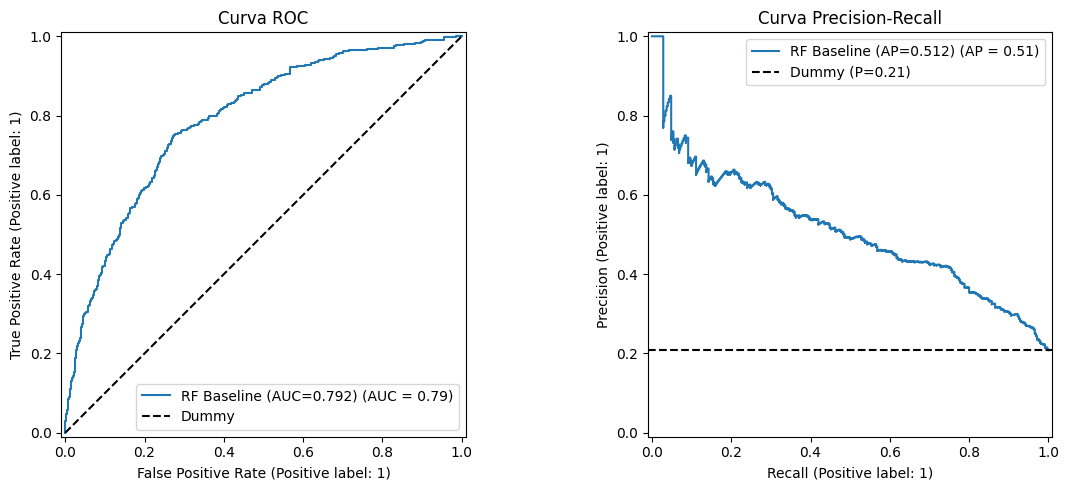

In [13]:
# Curvas ROC y Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_test,
    name=f'RF Baseline (AUC={test_auc:.3f})',
    ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Dummy')
axes[0].set_title('Curva ROC')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_test,
    name=f'RF Baseline (AP={test_ap:.3f})',
    ax=axes[1]
)
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='k', linestyle='--', label=f'Dummy (P={baseline_pr:.2f})')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

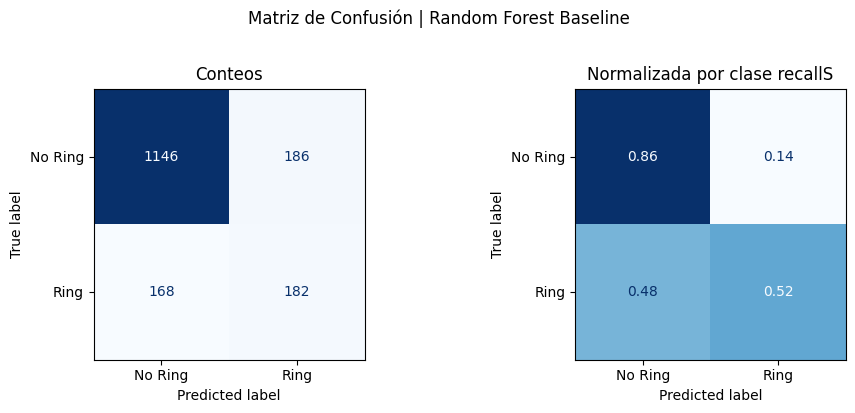

In [14]:
# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['No Ring', 'Ring'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Conteos')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['No Ring', 'Ring'],
    normalize='true', cmap='Blues', ax=axes[1], colorbar=False
)
axes[1].set_title('Normalizada por clase recallS')

plt.suptitle('Matriz de Confusión | Random Forest Baseline', y=1.02)
plt.tight_layout()
plt.show()

## Importancia de características

Se opto por permutation importance y no `feature_importances_` principalmente porque el dataset tiene alta colinealidad entre grupos de features (`img_*` y sus versiones `_std`, más `pca_*` que son proyecciones de las mismas). Con features correlacionadas, `feature_importances_` del árbol distribuye la importancia artificialmente entre ellas, subestimando cada una. Permutation importance mide el impacto real sobre el performance al perturbar cada feature individualmente.

In [17]:
perm_imp = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

perm_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance_mean': perm_imp.importances_mean,
    'importance_std': perm_imp.importances_std
}).sort_values('importance_mean', ascending=False)

print('Top 20 features por permutation importance:')
perm_df.head(20)

Top 20 features por permutation importance:


,feature,importance_mean,importance_std
71,lupton_saturation_mean_std,0.030118,0.010943
32,lupton_saturation_mean,0.016687,0.009548
15,img_g_log_p99_pos,0.008609,0.003706
75,lupton_lum_center_mean_std,0.008505,0.003495
54,img_g_log_p99_pos_std,0.008138,0.002552
94,pca_14,0.007975,0.003967
90,pca_10,0.007601,0.005070
87,pca_7,0.007352,0.002486
36,lupton_lum_center_mean,0.006470,0.002834
6,dec_cos,0.005400,0.001486


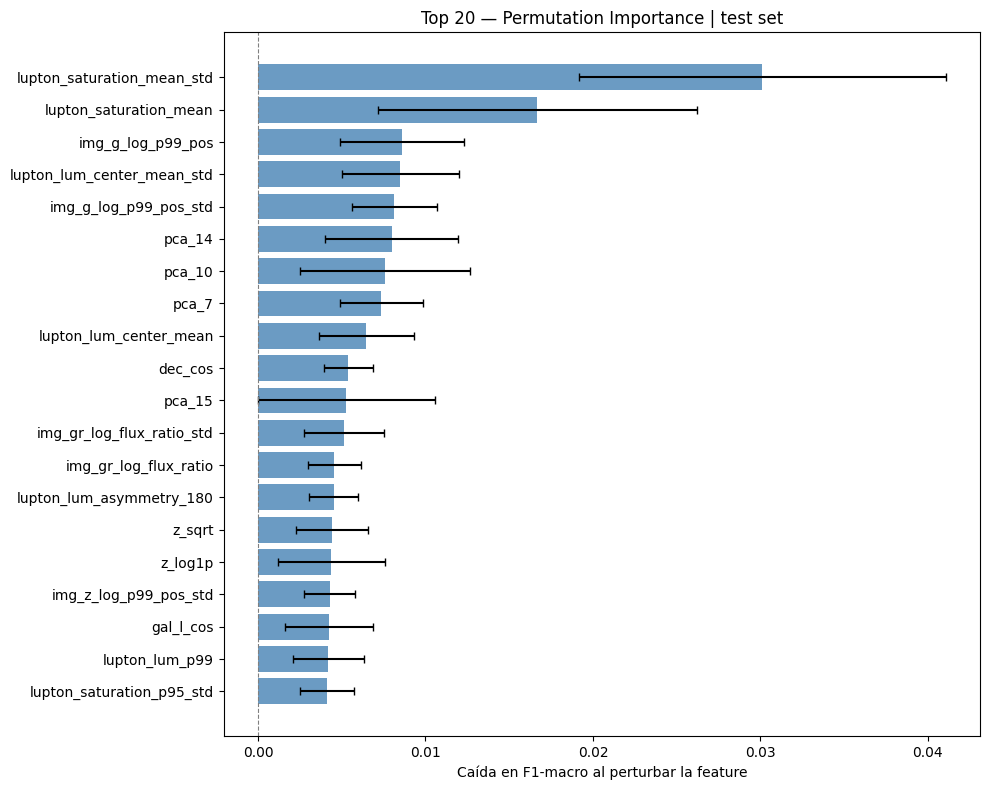

In [18]:
# Plot top 20 features
top20 = perm_df.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top20['feature'],
    top20['importance_mean'],
    xerr=top20['importance_std'],
    color='steelblue', alpha=0.8, capsize=3
)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Caída en F1-macro al perturbar la feature')
ax.set_title('Top 20 — Permutation Importance | test set')
plt.tight_layout()
plt.show()

In [19]:
# Features con importancia negativa o cercana a 0
low_imp = perm_df[perm_df['importance_mean'] <= 0.001]
print(f'Features con importancia ≤ 0.001 (candidatas a eliminar): {len(low_imp)}')
print(low_imp[['feature', 'importance_mean']].to_string(index=False))

Features con importancia ≤ 0.001 (candidatas a eliminar): 19
                    feature  importance_mean
                      pca_3         0.000943
  img_r_outer_to_inner_flux         0.000717
 img_r_concentration_20_std         0.000659
                 ra_sin_std         0.000547
            lupton_lum_mean         0.000519
                   z_bin_q3         0.000510
 img_r_peak_radius_norm_std         0.000305
      lupton_saturation_p95         0.000000
     img_r_peak_radius_norm        -0.000007
                      pca_4        -0.000020
                     pca_12        -0.000027
                     pca_17        -0.000104
         img_r_log_flux_pos        -0.000191
lupton_lum_peak_radius_norm        -0.000240
             lupton_lum_std        -0.000424
                   z_bin_q4        -0.000501
     img_g_log_flux_pos_std        -0.000665
                       fa_2        -0.000922
        img_r_asymmetry_180        -0.000928


### Métricas y benchmarks esperados

Tabla de referencia para evaluar el progreso hacia modelos más complejos.

In [20]:
dummy_f1  = f1_score(y_test, y_pred_dummy, average='macro')
dummy_auc = roc_auc_score(y_test, y_prob_dummy)
dummy_ap  = average_precision_score(y_test, y_prob_dummy)

summary = pd.DataFrame([
    {
        'Modelo': 'Dummy (estratificado)',
        'F1-macro': f'{dummy_f1:.4f}',
        'ROC-AUC': f'{dummy_auc:.4f}',
        'PR-AUC': f'{dummy_ap:.4f}',
        'Nota': 'Piso de referencia absoluto'
    },
    {
        'Modelo': 'Random Forest (baseline)',
        'F1-macro': f'{test_f1:.4f}',
        'ROC-AUC': f'{test_auc:.4f}',
        'PR-AUC': f'{test_ap:.4f}',
        'Nota': f'Gap train-test: {train_f1 - test_f1:.4f}'
    },
    {
        'Modelo': 'ResNet-50 ImageNet (esperado)',
        'F1-macro': '0.78–0.85',
        'ROC-AUC': '0.85–0.92',
        'PR-AUC': '—',
        'Nota': 'Transfer learning desde imágenes naturales'
    },
    {
        'Modelo': 'ZooBot ConvNeXt-nano (objetivo)',
        'F1-macro': '0.88–0.95',
        'ROC-AUC': '0.93–0.98',
        'PR-AUC': '—',
        'Nota': 'Pre-entrenado en Galaxy Zoo'
    },
])

print('=== Tabla comparativa de modelos ===')
print(summary.to_string(index=False))

=== Tabla comparativa de modelos ===
                         Modelo  F1-macro   ROC-AUC PR-AUC                                       Nota
          Dummy (estratificado)    0.4996    0.4997 0.2080                Piso de referencia absoluto
       Random Forest (baseline)    0.6866    0.7916 0.5117                     Gap train-test: 0.1871
  ResNet-50 ImageNet (esperado) 0.78–0.85 0.85–0.92      — Transfer learning desde imágenes naturales
ZooBot ConvNeXt-nano (objetivo) 0.88–0.95 0.93–0.98      —                Pre-entrenado en Galaxy Zoo


In [ ]:
# Criterio de desempeño mínimo
MIN_F1  = 0.70
MIN_AUC = 0.80

f1_ok  = test_f1  >= MIN_F1
auc_ok = test_auc >= MIN_AUC

print('Evaluación contra desempeño mínimo')
print(f'F1-macro  ≥ {MIN_F1}: {"CUMPLE" if f1_ok  else "NO CUMPLE"} ({test_f1:.4f})')
print(f'ROC-AUC   ≥ {MIN_AUC}: {"CUMPLE" if auc_ok else "NO CUMPLE"} ({test_auc:.4f})')

if f1_ok and auc_ok:
    print('\nBaseline aceptable. Las features engineered contienen información predictiva suficiente.')
    print('Siguiente paso: baseline de imagen con ResNet-50 fine-tuned desde ImageNet.')
else:
    print('\nBaseline por debajo del mínimo. Revisar:')
    print('  - Calidad de las features de imagen (img_*, lupton_*)')
    print('  - Posible data leakage o errores en el split')
    print('  - Considerar pasar directamente al modelo de imagen (raw FITS)')

Evaluación contra desempeño mínimo
F1-macro  ≥ 0.7: NO CUMPLE (0.6866)
ROC-AUC   ≥ 0.8: NO CUMPLE (0.7916)

Baseline por debajo del mínimo. Revisar:
  - Calidad de las features de imagen (img_*, lupton_*)
  - Posible data leakage o errores en el split
  - Considerar pasar directamente al modelo de imagen (raw FITS)
